# 04. Análisis exploratorio

Genera resúmenes estadísticos, percentiles y gráficos para entender distribución de eventos, intervalos y comportamiento por bus.


In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
PLOTS_DIR = PROJECT_ROOT / "outputs" / "plots"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

for directory in [DATA_PROCESSED_DIR, MODELS_DIR, PLOTS_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


In [7]:
base_df = pd.read_parquet(DATA_PROCESSED_DIR / "base.parquet")
eventos_df = pd.read_parquet(DATA_PROCESSED_DIR / "eventos.parquet")
features_df = pd.read_parquet(DATA_PROCESSED_DIR / "features.parquet")

summary = pd.Series(
    {
        "total_registros_ejecutados": len(base_df),
        "preventivos_ejecutados": int(base_df["tipo_revision"].eq("PREVENTIVO").sum()),
        "correctivos_ejecutados": int(base_df["tipo_revision"].eq("CORRECTIVO").sum()),
        "eventos_tecnicos_unicos": len(eventos_df),
        "buses_unicos": int(base_df["placa_patente"].nunique()),
        "fecha_min": base_df["fecha_evento"].min(),
        "fecha_max": base_df["fecha_evento"].max(),
    }
)

eventos_por_bus = base_df.groupby("placa_patente").size()
correctivos_por_bus = eventos_df.groupby("placa_patente").size()
intervalos = eventos_df["dias_desde_correctivo_anterior"].dropna()
intervalo_por_bus = (
    eventos_df.groupby("placa_patente")["dias_desde_correctivo_anterior"].mean().dropna()
)

print("Resumen general:")
display(summary.to_frame(name="valor"))

print("Eventos por bus:")
display(
    pd.Series(
        {
            "promedio": eventos_por_bus.mean(),
            "mediana": eventos_por_bus.median(),
            "maximo": eventos_por_bus.max(),
        }
    ).to_frame(name="valor")
)

print("Correctivos técnicos por bus:")
display(
    pd.Series(
        {
            "promedio": correctivos_por_bus.mean(),
            "mediana": correctivos_por_bus.median(),
            "maximo": correctivos_por_bus.max(),
        }
    ).to_frame(name="valor")
)

print("Percentiles intervalos globales:")
display(intervalos.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).to_frame(name="dias"))

print("Percentiles del promedio de intervalo por bus:")
display(intervalo_por_bus.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).to_frame(name="dias"))

print("Top 10 buses con más correctivos:")
display(correctivos_por_bus.sort_values(ascending=False).head(10).to_frame(name="correctivos"))


Resumen general:


,valor
total_registros_ejecutados,15026
preventivos_ejecutados,526
correctivos_ejecutados,14500
eventos_tecnicos_unicos,12207
buses_unicos,735
fecha_min,2024-11-05 12:34:28
fecha_max,2025-12-31 20:53:00


Eventos por bus:


,valor
promedio,20.443537
mediana,16.000000
maximo,88.000000


Correctivos técnicos por bus:


...

,dias
0.10,1.000000
0.25,1.535958
0.50,3.542384
0.75,7.809919
0.90,17.000000


Percentiles del promedio de intervalo por bus:


,dias
0.10,4.507906
0.25,5.879436
0.50,7.773069
0.75,10.939792
0.90,14.083492


Top 10 buses con más correctivos:


,correctivos
placa_patente,
PFVL15,64
PFVK90,60
PDZH97,54
PFTF88,54
PFVL21,51
PFYH17,51
PFYG91,46
PFVK64,46
PFBG33,45


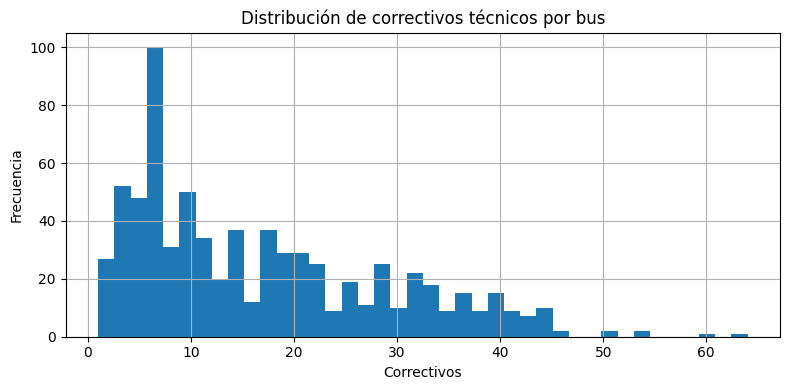

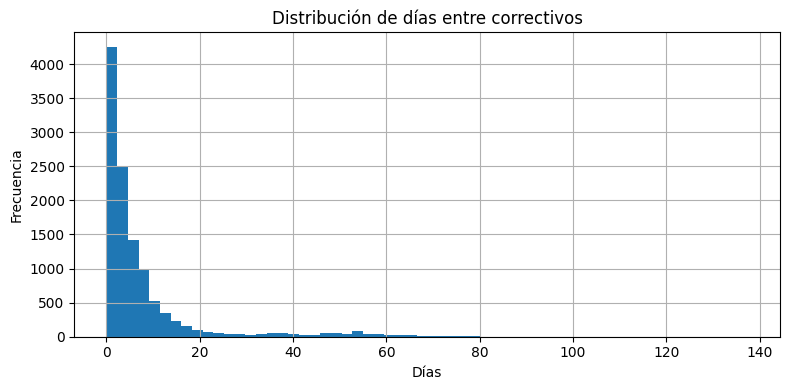

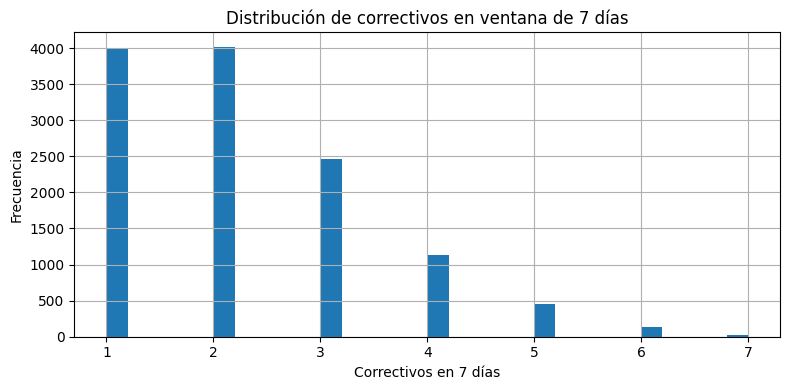

In [8]:
plt.figure(figsize=(8, 4))
correctivos_por_bus.hist(bins=40)
plt.title("Distribución de correctivos técnicos por bus")
plt.xlabel("Correctivos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "distribucion_correctivos_por_bus.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
intervalos.hist(bins=60)
plt.title("Distribución de días entre correctivos")
plt.xlabel("Días")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "intervalos_entre_correctivos.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
features_df["correctivos_ult_7d"].hist(bins=30)
plt.title("Distribución de correctivos en ventana de 7 días")
plt.xlabel("Correctivos en 7 días")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "rolling_correctivos_7d.png", dpi=150)
plt.show()
